<a href="https://colab.research.google.com/github/LeonimerMelo/Reinforcement-Learning/blob/On-Policy-Algorithm/SARSA_On_Policy_Algorithm_(RL)_v6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#SARSA - On-Policy Algorithm

**SARSA** é o primeiro algoritmo baseado em valor abordado. Ele foi criado por **Rummery e Niranjan** em seu artigo de 1994, *“On-Line Q-Learning Using Connectionist Systems”*. O nome **SARSA** reflete o fato de que o algoritmo requer a sequência **Estado-Ação-Recompensa-Estado-Ação** para realizar uma atualização.

<center>
<img src='https://drive.google.com/uc?id=10wx1qYZwHk-IRO9O6O-ccCy8rS1qcXfS' width=700>
</center>

## **Algoritmos Baseados em Valor**
- Esses algoritmos avaliam pares estado-ação $(s, a)$ aprendendo uma das funções de valor:  
  - $ V^\pi(s) $: valor de um estado sob uma política $ \pi $.  
  - $ Q^\pi(s, a) $: valor de uma ação específica em um estado, sob a política $ \pi $.  

- O SARSA aprende $ Q^\pi(s, a) $, enquanto outros algoritmos, como o **Actor-Critic**, aprendem $ V^\pi(s) $.

<center>
<img src='https://drive.google.com/uc?id=1dFpdXP9XFiyV9f7jof4xQXgfDb7DiogP' width=600>
</center>

## **Principais Ideias do SARSA**
O algoritmo é baseado em dois conceitos fundamentais:

### 1. **Aprendizado por Diferença Temporal (TD)**
- O aprendizado por diferença temporal é uma técnica usada para estimar valores de estado ou valores de pares estado-ação com base nas experiências que o agente coleta no ambiente.
- Essa técnica é uma alternativa ao **método Monte Carlo**, que também estima valores, mas **exige episódios completos**.

<center>
<img src='https://drive.google.com/uc?id=181TK4CkNJTIai107JneQH0mDmRzvm1MD' width=600>
</center>

### 2. **Geração de Ações com Base na Função $ Q $**
- O algoritmo utiliza a função $ Q $ para decidir quais ações tomar.
- Isso levanta o problema do equilíbrio entre:
  - **Exploration:** aprender mais sobre o ambiente.
  - **Exploitation:** usar o que o agente já sabe para maximizar a recompensa.
- Esse dilema é conhecido como o **exploration-exploitation tradeoff**.
- Uma abordagem simples para resolver o problema é a **política ε-greedy**, que mistura exploration-exploitation com base em uma probabilidade $ ε $.

<center>
<img src='https://drive.google.com/uc?id=1a0sXlS1iu8Oo4ukBwJ87qKQL82U31_kz' width=500>
</center>

O **SARSA** (State-Action-Reward-State-Action) é um algoritmo de aprendizado por reforço **on-policy** utilizado para resolver problemas de controle, como encontrar uma política ótima em um ambiente de tomada de decisão. Ele é baseado no **Q-learning**, mas com uma diferença chave: **o SARSA segue a política que está sendo avaliada e melhorada**.

## **Como o SARSA Funciona**
O nome do algoritmo vem da sequência que ele utiliza para atualizar os valores de $ Q(s, a): (s_t, a_t, r_{t+1}, s_{t+1}, a_{t+1})$

Esses termos representam:
- $ s_t $: o estado atual.
- $ a_t $: a ação tomada no estado atual.
- $ r_{t+1} $: a recompensa recebida ao tomar a ação $ a_t $.
- $ s_{t+1} $: o próximo estado alcançado.
- $ a_{t+1} $: a próxima ação escolhida pela política no estado $ s_{t+1} $.

<center>
<img src='https://drive.google.com/uc?id=1DIJJgpJ7IKTaPSm7p31JpCjeyYeLBjoQ' width=700>
</center>

### **Atualização da Função Q**
O SARSA utiliza a seguinte fórmula para atualizar os valores de $ Q(s, a) $:
$$
Q(s_t, a_t) \gets Q(s_t, a_t) + \alpha \left[ r_{t+1} + \gamma Q(s_{t+1}, a_{t+1}) - Q(s_t, a_t) \right]
$$
Onde:
- $ \alpha $: taxa de aprendizado ($ 0 < \alpha \leq 1 $).
- $ \gamma $: fator de desconto ($ 0 \leq \gamma \leq 1 $).
- $ r_{t+1} + \gamma Q(s_{t+1}, a_{t+1}) $: **retorno esperado** para a próxima etapa da política.

Essa atualização é feita iterativamente para ajustar os valores $ Q(s, a) $ até convergir para uma política ótima.

---

### **Diferença entre SARSA e Q-Learning**
A principal diferença entre Q-learning e Sarsa está no valor-alvo:
- **SARSA (On-policy):** A atualização de $ Q(s, a) $ usa a ação $ a_{t+1} $, que é selecionada pela **mesma política atual** que está sendo aprendida.
- **Q-Learning (Off-policy):** A atualização de $ Q(s, a) $ usa a ação que maximiza $ Q(s', a') → \max_a Q(s_{t+1}, a_{t+1}) $, independentemente da política atual.
A fórmula de atualização do Q-learning:
$$
Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r_{t+1} + \gamma \max_{a'} Q(s_{t+1}, a_{t+1}) - Q(s, a) \right]
$$

**Exemplo prático:**
- Se a política atual for exploratória ($\epsilon$-greedy), o SARSA levará em conta essa exploração. Já o Q-Learning assume que a ação ótima será sempre tomada no próximo estado.

---

### **Fluxo do Algoritmo SARSA**

1. **Inicialização:**
   - Inicialize a tabela $ Q(s, a) $ com valores arbitrários (ex.: zeros).
   - Escolha o estado inicial $ s_0 $.

2. **Interação com o Ambiente:**
   - Para cada episódio:
     1. Escolha uma ação $ a_t $ com base na política atual (ex.: $\epsilon$-greedy).
     2. Execute a ação $ a_t $ e observe $ r_{t+1} $ (recompensa) e $ s_{t+1} $ (próximo estado).
     3. Escolha a próxima ação $ a_{t+1} $ usando a política atual.
     4. Atualize $ Q(s_t, a_t) $ usando a fórmula de atualização.
     5. Atualize $ s_t \gets s_{t+1} $ e $ a_t \gets a_{t+1} $.

3. **Repetição:**
   - Continue até convergir para uma política estável ou atingir o número máximo de episódios.

---

### **Pseudocódigo do SARSA**
```python
Inicializar Q(s, a) arbitrariamente
Para cada episódio:
    Inicializar s
    Escolher a a partir de s usando política derivada de Q (ex.: ε-greedy)
    Enquanto s não for terminal:
        Executar a, observar r e s'
        Escolher a' a partir de s' usando política derivada de Q (ex.: ε-greedy)
        Atualizar Q(s, a): Q(s, a) += α [r + γ Q(s', a') - Q(s, a)]
        s <- s'
        a <- a'
```

---

### **Exemplo Prático em Python**
Aqui está uma implementação básica do SARSA para resolver o problema do ambiente `CliffWalking-v0` do Gym:

In [ ]:
pip install gymnasium -q

In [ ]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

In [ ]:
# anbiente de simulação
max_episode_steps_ = 500 # truncate afther this
env = gym.make('CliffWalking-v0', render_mode='rgb_array', max_episode_steps = max_episode_steps_)

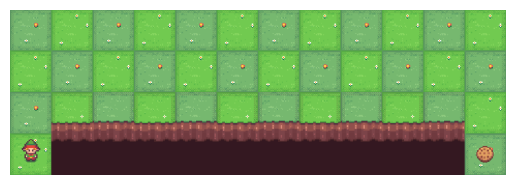

In [ ]:
env.reset()
plt.imshow(env.render())
plt.axis('off')
plt.show()

0: Move up, 1: Move right, 2: Move down, 3: Move left
Política final (ações por estado): [1 1 1 1 1 1 1 1 1 1 1 2 0 1 1 1 1 1 1 1 1 1 1 2 0 1 0 0 3 0 0 3 1 1 1 2 0
 0 0 0 0 0 0 0 0 0 0 0]




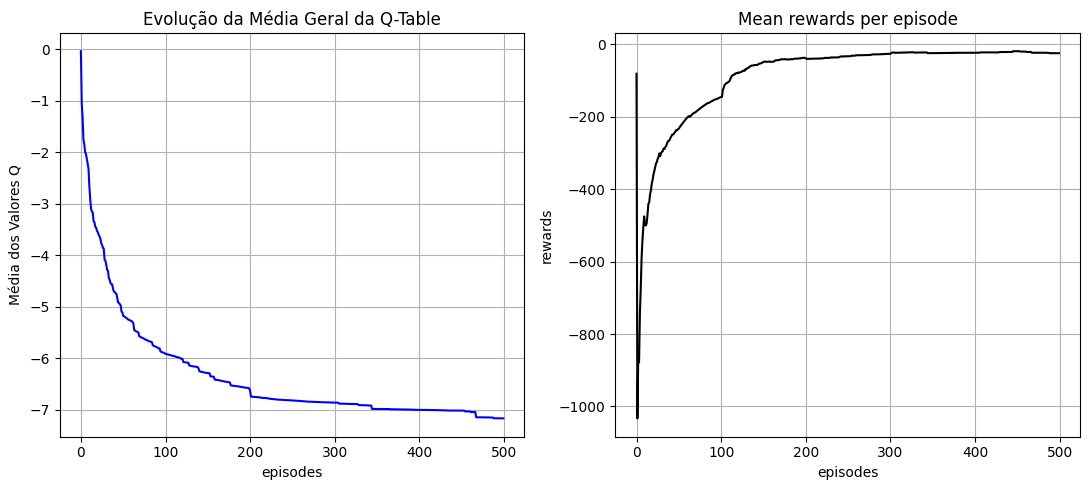

In [ ]:
# Parâmetros
num_episodes = 500
alpha = 0.1
gamma = 0.9
epsilon = 0.1
q_table_history = []
rewards_per_episode = []     # list to store rewards for each episode

Q = np.zeros((env.observation_space.n, env.action_space.n))  # Inicializa Q

def epsilon_greedy_policy(Q, state, n_actions, epsilon):
    if np.random.rand() < epsilon:
        return np.random.choice(n_actions)  # Exploration
    else:
        return np.argmax(Q[state])  # Exploitation baseada em Q

# Treinamento
for episode in range(num_episodes):
    state, _ = env.reset()
    action = epsilon_greedy_policy(Q, state, env.action_space.n, epsilon)
    done = False
    rewards = 0
    while not done:
        next_state, reward, terminated, truncated, _ = env.step(action)
        next_action = epsilon_greedy_policy(Q, next_state, env.action_space.n, epsilon)

        # Atualiza Q usando a fórmula do SARSA
        Q[state, action] += alpha * (reward + gamma * Q[next_state, next_action] - Q[state, action])

        state = next_state
        action = next_action

        rewards += reward
        done =  terminated or truncated

    q_table_history.append(np.mean(Q))  # Armazenar média geral da Q-Table
    rewards_per_episode.append(rewards) # Store rewards per episode

env.close()

# Política aprendida
policy = np.argmax(Q, axis=1)
print('0: Move up, 1: Move right, 2: Move down, 3: Move left')
print("Política final (ações por estado):", policy)
print('\n')

# Graph mean rewards
mean_rewards_ = []
for t in range(num_episodes):
    # calculo a média móvel dos rewards de 100 episódios
    mean_rewards_.append(np.mean(rewards_per_episode[max(0, t-100):(t+1)]))

plt.figure(figsize = (11,5))
plt.subplot(1,2,1)
plt.plot(q_table_history, label="Média Geral da Q-Table", color="blue")
plt.title("Evolução da Média Geral da Q-Table")
plt.xlabel("episodes")
plt.ylabel("Média dos Valores Q")
plt.xticks()
plt.yticks()
plt.grid()
plt.subplot(1,2,2)
plt.title('Mean rewards per episode')
plt.xlabel('episodes')
plt.ylabel('rewards')
plt.plot(mean_rewards_, color="black")
plt.xticks()
plt.yticks()
plt.tight_layout()
plt.grid()
plt.show()

### Imprimindo a Q-Table
Cada linha da tabela representa um estado, e cada valor na linha representa o valor $ Q(s, a) $ associado às ações disponíveis no estado.

In [ ]:
# Imprimindo a Q-Table após o treinamento
print("Q-Table após o treinamento:")
# o ambiente tem 48 estados (CliffWalking-v0)
for state in range(env.observation_space.n):
    print(f"Estado {state}: {Q[state]}")

Q-Table após o treinamento:
Estado 0: [-7.83585953 -7.80522663 -7.91316719 -7.89585818]
Estado 1: [-7.61519616 -7.56622666 -7.82640105 -7.68000083]
Estado 2: [-7.35960119 -7.30184444 -7.45222921 -7.45301499]
Estado 3: [-7.0883149  -6.98533074 -7.16939556 -7.09158616]
Estado 4: [-6.83028812 -6.62911392 -6.68912373 -6.81007126]
Estado 5: [-6.41848851 -6.23893043 -6.33748944 -6.3707811 ]
Estado 6: [-6.04862795 -5.82366387 -5.87399126 -6.25944065]
Estado 7: [-5.50381709 -5.35905781 -5.37618815 -5.73211039]
Estado 8: [-5.06526573 -4.8213878  -4.83147527 -5.11518068]
Estado 9: [-4.41482139 -4.24895907 -4.27845021 -4.6682619 ]
Estado 10: [-3.72174306 -3.57434322 -3.64431846 -4.15665971]
Estado 11: [-3.09724355 -3.05545186 -2.81025475 -3.37826639]
Estado 12: [-8.03065427 -8.15104039 -8.45743861 -8.10894521]
Estado 13: [-7.65726978 -7.45275642 -9.06868496 -7.67067862]
Estado 14: [-7.36261087 -7.04718126 -8.56906898 -7.35190146]
Estado 15: [-6.90776385 -6.71737956 -8.35890548 -6.98648472]
Estado

In [ ]:
import pandas as pd

# Convertendo a Q-Table para um DataFrame para visualização mais clara
acao=['UP', 'RIGHT', 'DOWN', 'LEFT']
q_table_df = pd.DataFrame(Q, columns=[f"{acao[i]}" for i in range(env.action_space.n)])
print("Q-Table formatada:")
print(q_table_df)

Q-Table formatada:
          UP      RIGHT       DOWN      LEFT
0  -7.835860  -7.805227  -7.913167 -7.895858
1  -7.615196  -7.566227  -7.826401 -7.680001
2  -7.359601  -7.301844  -7.452229 -7.453015
3  -7.088315  -6.985331  -7.169396 -7.091586
4  -6.830288  -6.629114  -6.689124 -6.810071
5  -6.418489  -6.238930  -6.337489 -6.370781
6  -6.048628  -5.823664  -5.873991 -6.259441
7  -5.503817  -5.359058  -5.376188 -5.732110
8  -5.065266  -4.821388  -4.831475 -5.115181
9  -4.414821  -4.248959  -4.278450 -4.668262
10 -3.721743  -3.574343  -3.644318 -4.156660
11 -3.097244  -3.055452  -2.810255 -3.378266
12 -8.030654  -8.151040  -8.457439 -8.108945
13 -7.657270  -7.452756  -9.068685 -7.670679
14 -7.362611  -7.047181  -8.569069 -7.351901
15 -6.907764  -6.717380  -8.358905 -6.986485
16 -6.445135  -6.368902  -9.073631 -6.416175
17 -6.076696  -5.973330  -6.052870 -6.086880
18 -5.630023  -5.471206  -6.012939 -5.613173
19 -5.204534  -4.954640  -5.215745 -5.459289
20 -4.571200  -4.285791  -5.866252 -

Se quisermos exibir os valores ótimos da **Q-Table** no formato de um grid **4x12** (como no ambiente **CliffWalking-v0**), podemos mapear os valores ótimos $ \max(Q(s, a)) $ de cada estado para suas respectivas posições no grid. Abaixo o código para imprimir o **4x12 grid** com os valores ótimos da Q-Table:

In [ ]:
# Função para imprimir o grid 4x12 com os índices das ações no grid 4x12
def print_optimal_values(q_table, rows, cols):
    optimal_values = np.argmax(q_table, axis=1)  # Seleciona o índice ótimo (argmax Q) para cada estado
    grid = optimal_values.reshape((rows, cols))  # Reshape para o formato do grid (4x12)

    print("índices de ações ótimas (argmax Q) no formato 4x12 grid:")
    for row in grid:
        print('-------------------------------------------------')
        print('|', " | ".join(f"{value:d}" for value in row), '|')
    print('-------------------------------------------------')

print('0: Move up')
print('1: Move right')
print('2: Move down')
print('3: Move left\n')

# Imprimir o grid com valores ótimos
print_optimal_values(Q, rows=4, cols=12)

0: Move up
1: Move right
2: Move down
3: Move left

índices de ações ótimas (argmax Q) no formato 4x12 grid:
-------------------------------------------------
| 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 2 |
-------------------------------------------------
| 0 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 2 |
-------------------------------------------------
| 0 | 1 | 0 | 0 | 3 | 0 | 0 | 3 | 1 | 1 | 1 | 2 |
-------------------------------------------------
| 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 |
-------------------------------------------------


#### Explicação do Código
1. **Seleção dos Valores Ótimos**:
   - Usamos `np.argmax(q_table, axis=1)` para selecionar o índice de maior valor de $ Q(s, a) $ para cada estado $ s $.
   
2. **Formatação em Grid**:
   - Usamos `.reshape((rows, cols))` para reorganizar os valores em um formato 4x12.

3. **Impressão do Grid**:
   - Cada linha é formatada para mostrar os valores do índices das ações.

### Adicionando Direções das Ações
Para se exibir as ações ótimas (política aprendida) em vez dos valores $ Q $, substitua por `np.argmax` para obter a ação ótima de cada estado.


In [ ]:
def print_optimal_policy(q_table, rows, cols, actions=["↑", "→", "↓", "←", "G", "S", "C"]):
    optimal_actions = np.argmax(q_table, axis=1)  # Seleciona as ações ótimas
    grid = optimal_actions.reshape((rows, cols))
    for i in range(cols):
      grid[rows-1,i]=6
    grid[rows-1,cols-1]=4
    grid[rows-1,0]=5

    print("Política ótima no formato 4x12 grid:")
    for row in grid:
        print('-------------------------------------------------')
        print('|', " | ".join(f"{actions[action]}" for action in row), '|')
    print('-------------------------------------------------')

# Exibir a política ótima
print_optimal_policy(Q, rows=4, cols=12)

Política ótima no formato 4x12 grid:
-------------------------------------------------
| → | → | → | → | → | → | → | → | → | ↓ | ↓ | ↓ |
-------------------------------------------------
| → | ↑ | → | ↑ | → | ↑ | → | → | → | → | → | ↓ |
-------------------------------------------------
| ↑ | → | ↑ | ↑ | → | ↑ | ↑ | ↑ | ↑ | ↑ | ↑ | ↓ |
-------------------------------------------------
| S | C | C | C | C | C | C | C | C | C | C | G |
-------------------------------------------------


- Cada símbolo representa a ação ótima para o estado $( ↑, →, ↓, ← )$.
- O "G" representa a meta no ambiente, o "S" o start e o "C" o `cliff`

### **Vantagens do SARSA**
1. **Aprendizado seguro:** Como considera a política atual, SARSA tende a ser mais seguro e evita explorar áreas perigosas (ex.: no CliffWalking).
2. **Exploração consistente:** Reflete a natureza exploratória da política ($\epsilon$-greedy).

### **Desvantagens**
1. Pode levar mais tempo para convergir, pois depende da política exploratória.
2. Geralmente, o desempenho é inferior ao do Q-Learning em ambientes onde ações exploratórias não são tão relevantes.

##Referências
- https://drive.google.com/drive/folders/1HXKytyslsu4csngdT1BnGQ9fx9QOAQmA?usp=drive_link

##Exercícios
1. Alterar os hiperparâmetros e observar os resultados.
1. A política ótima foi alcançada?
1. Aplicar o algoritmo SARSA nos ambientes `gymnasium frozenlake` e `taxi` e comparar os resultados com os obtidos com o algoritmo Q-Learning
